In [1]:
# %matplotlib widget
import sys
sys.path.append('..')

import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm

In [2]:
de = np.load("DE_spctrum.npz")

In [3]:
de['DE_pe_spec'] ,

(array([0.08452372, 0.06166224, 0.03902846, 0.01981025, 0.01329791,
        0.00728653, 0.00464516, 0.00236812, 0.00241366, 0.00145731,
        0.00059203, 0.00059203, 0.00086528, 0.00059203, 0.00086528,
        0.00050095, 0.00086528, 0.00068311, 0.00027324, 0.00031879,
        0.00013662]),)

In [4]:
de['DE_pe_spec'],de['DE_bins_edge']

(array([0.08452372, 0.06166224, 0.03902846, 0.01981025, 0.01329791,
        0.00728653, 0.00464516, 0.00236812, 0.00241366, 0.00145731,
        0.00059203, 0.00059203, 0.00086528, 0.00059203, 0.00086528,
        0.00050095, 0.00086528, 0.00068311, 0.00027324, 0.00031879,
        0.00013662]),
 array([ 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210,
        220, 230, 240, 250, 260, 270, 280, 290, 300]))

In [5]:
keys = de.keys()
print(keys)

KeysView(<numpy.lib.npyio.NpzFile object at 0x7f2da0734f40>)


Acceptance分析
=====

In [27]:
result = np.load("Cut_acceptance.npz")

ratio_3 = result['ratio_3']
ratio_4 = result['ratio_4']
ratio_5 = result['ratio_5']
ratio_6 = result['ratio_6']
ratio_7 = result['ratio_7']
ratio_8 = result['ratio_8']
ratio_9 = result['ratio_9']
z_edges = result['z_edges']
pe_edges = result['pe_edges']

In [28]:
ratio_3

array([[0.00194994, 0.00390898, 0.00737526, 0.01242068, 0.01923685,
        0.02148612, 0.03361345, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.00706241, 0.01481003, 0.02705699, 0.05006843, 0.07554772,
        0.11438475, 0.14038128, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.00988301, 0.02154748, 0.04233903, 0.07334991, 0.11607311,
        0.1729985 , 0.2369403 , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.01085642, 0.02467689, 0.05034997, 0.08794317, 0.14130572,
        0.2047849 , 0.27747253, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.01130017, 0.02568939, 0.05117264, 0.09498305, 0.15971696,
        0.22626   , 0.29773157, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.01093015, 0.02527796, 0.0

In [7]:
z_edges

array([  0.,  24.,  48.,  72.,  96., 120., 144., 168., 192., 216., 240.])

In [8]:
pe_edges

array([ 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210,
       220, 230])

In [9]:
len(pe_edges),len(ratio_3[0])

(15, 14)

In [10]:
PE_3 = np.random.normal(90, 8 * 3**0.5, 1000000)
PE_4 = np.random.normal(120, 8 * 4**0.5, 1000000)
PE_5 = np.random.normal(150, 8 * 5**0.5, 1000000)
PE_6 = np.random.normal(180, 8 * 6**0.5, 1000000)
PE_7 = np.random.normal(210, 8 * 7**0.5, 1000000)
PE_8 = np.random.normal(240, 8 * 8**0.5, 1000000)
PE_9 = np.random.normal(270, 8 * 9**0.5, 1000000)

In [11]:
PE_3_bins = np.histogram(PE_3,bins = pe_edges)
PE_4_bins = np.histogram(PE_4,bins = pe_edges)
PE_5_bins = np.histogram(PE_5,bins = pe_edges)
PE_6_bins = np.histogram(PE_6,bins = pe_edges)
PE_7_bins = np.histogram(PE_7,bins = pe_edges)
PE_8_bins = np.histogram(PE_8,bins = pe_edges)
PE_9_bins = np.histogram(PE_9,bins = pe_edges)

PE_3_bins_remain = PE_3_bins[0] * ratio_3
PE_4_bins_remain = PE_4_bins[0] * ratio_4
PE_5_bins_remain = PE_5_bins[0] * ratio_5
PE_6_bins_remain = PE_6_bins[0] * ratio_6
PE_7_bins_remain = PE_7_bins[0] * ratio_7
PE_8_bins_remain = PE_8_bins[0] * ratio_8
PE_9_bins_remain = PE_9_bins[0] * ratio_9

In [12]:
np.sum(PE_3_bins[0][3:]) / 1000000

0.015307

In [13]:
ratio_roi_area = np.array([np.sum(PE_3_bins[0][3:]),
                           np.sum(PE_4_bins[0][3:]),
                           np.sum(PE_5_bins[0][3:]),
                           np.sum(PE_6_bins[0][3:]),
                           np.sum(PE_7_bins[0][3:]),
                           np.sum(PE_8_bins[0][3:]),
                           np.sum(PE_9_bins[0][3:])]) / 1000000

In [14]:
ratio_roi_area

array([0.015307, 0.499448, 0.953195, 0.993503, 0.827543, 0.328968,
       0.047553])

In [15]:
ratio_3_z = np.sum(PE_3_bins_remain,axis = 1)/np.sum(PE_3_bins[0])
ratio_4_z = np.sum(PE_4_bins_remain,axis = 1)/np.sum(PE_4_bins[0])
ratio_5_z = np.sum(PE_5_bins_remain,axis = 1)/np.sum(PE_5_bins[0])
ratio_6_z = np.sum(PE_6_bins_remain,axis = 1)/np.sum(PE_6_bins[0])
ratio_7_z = np.sum(PE_7_bins_remain,axis = 1)/np.sum(PE_7_bins[0])
ratio_8_z = np.sum(PE_8_bins_remain,axis = 1)/np.sum(PE_8_bins[0])
ratio_9_z = np.sum(PE_9_bins_remain,axis = 1)/np.sum(PE_9_bins[0])

ratio_3_z_roi = np.sum(PE_3_bins_remain[:,3:],axis = 1)/np.sum(PE_3_bins[0][3:])
ratio_4_z_roi = np.sum(PE_4_bins_remain[:,3:],axis = 1)/np.sum(PE_4_bins[0][3:])
ratio_5_z_roi = np.sum(PE_5_bins_remain[:,3:],axis = 1)/np.sum(PE_5_bins[0][3:])
ratio_6_z_roi = np.sum(PE_6_bins_remain[:,3:],axis = 1)/np.sum(PE_6_bins[0][3:])
ratio_7_z_roi = np.sum(PE_7_bins_remain[:,3:],axis = 1)/np.sum(PE_7_bins[0][3:])
ratio_8_z_roi = np.sum(PE_8_bins_remain[:,3:],axis = 1)/np.sum(PE_8_bins[0][3:])
ratio_9_z_roi = np.sum(PE_9_bins_remain[:,3:],axis = 1)/np.sum(PE_9_bins[0][3:])

ratio = np.array([ratio_3_z,ratio_4_z,ratio_5_z,ratio_6_z,ratio_7_z,ratio_8_z,ratio_9_z])
ratio_roi = np.array([ratio_3_z_roi,ratio_4_z_roi,ratio_5_z_roi,ratio_6_z_roi,ratio_7_z_roi,ratio_8_z_roi,ratio_9_z_roi])

In [16]:
data = np.load("../cevns_sim.npz")
k_3,k_3_roi = np.sum(PE_3_bins[0]) / 1e6,np.sum(PE_3_bins[0][3:]) / 1e6
k_4,k_4_roi = np.sum(PE_4_bins[0]) / 1e6,np.sum(PE_4_bins[0][3:]) / 1e6
k_5,k_5_roi = np.sum(PE_5_bins[0]) / 1e6,np.sum(PE_5_bins[0][3:]) / 1e6
k_6,k_6_roi = np.sum(PE_6_bins[0]) / 1e6,np.sum(PE_6_bins[0][3:]) / 1e6
k_7,k_7_roi = np.sum(PE_7_bins[0]) / 1e6,np.sum(PE_7_bins[0][3:]) / 1e6
k_8,k_8_roi = np.sum(PE_8_bins[0]) / 1e6,np.sum(PE_8_bins[0][3:]) / 1e6
k_9,k_9_roi = np.sum(PE_9_bins[0]) / 1e6,np.sum(PE_9_bins[0][3:]) / 1e6
weight = data['CEvNS'][3:10] * np.array([k_3,k_4,k_5,k_6,k_7,k_8,k_9])
weight_roi = data['CEvNS'][3:10] * np.array([k_3_roi,k_4_roi,k_5_roi,k_6_roi,k_7_roi,k_8_roi, k_9_roi])

In [17]:
ratio_e = np.mean(ratio,axis = 1)
ratio_z = np.average(ratio,axis = 0,weights = weight)
ratio_e_roi = np.mean(ratio_roi,axis = 1)
ratio_z_roi = np.average(ratio_roi,axis = 0,weights = weight_roi)

In [19]:
e_bins = np.arange(3,10,1)
z_bins = (z_edges[1:] + z_edges[:-1])/2

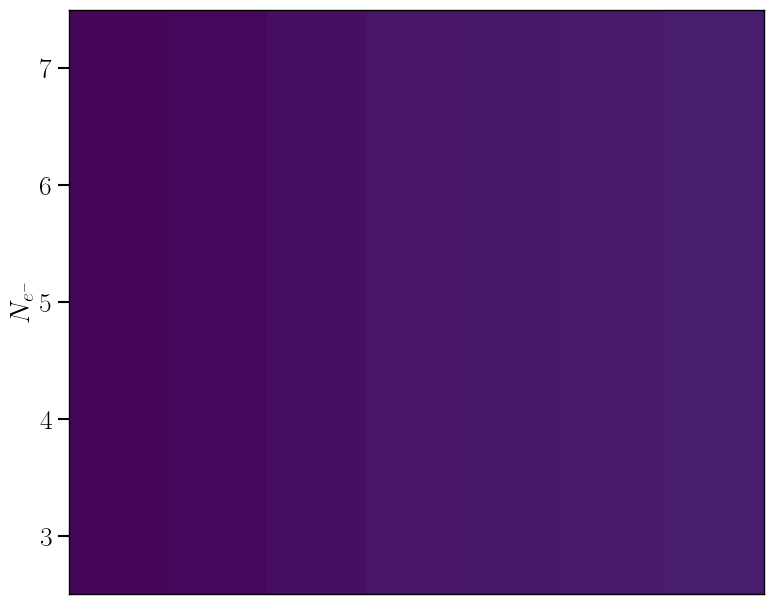

In [20]:
from matplotlib import colors
norm = colors.Normalize(vmin=0, vmax=100)
fig = plt.figure(figsize=(18,9))
plt.style.use('../relics.mplstyle') 
gs = matplotlib.gridspec.GridSpec(3,3, height_ratios=[0.05,0.75,0.15], width_ratios=[0.7,0.15,0.75])
gs.update(left=0.05, right=0.95, bottom=0.08, top=0.93, wspace=0.03, hspace=0.05)

ax1 = plt.subplot(gs[1,0])
mesh = ax1.pcolormesh(e_bins, z_bins, ratio_roi.T * 100,norm = norm)

# 设置 x 和 y 轴
ax1.set_xticks(np.arange(0, 288, 48))
ax1.set_xticklabels([])
ax1.set_yticks(np.arange(3, 8, 1))
ax1.set_yticklabels([r'${}$'.format(i) for i in np.arange(3, 8, 1)])
ax1.set_ylabel(r'$N_{e^{-}}$')
ax1.set_ylim([2.5,7.5])

# cbax = plt.subplot(gs[0,0])
# # 为 colorbar 创建 colorbar
# cbar = plt.colorbar(mappable=mesh, cax=cbax, orientation='horizontal', ticklocation='top')
# cbar.set_ticks([0, 25, 50, 75, 100])
# cbar.set_ticklabels([r'${}\%$'.format(i) for i in np.arange(0, 1.25, 0.25)*100])

# ax1v = plt.subplot(gs[1,1])
# ax1v.plot(ratio_e_roi * 100,np.arange(3,8,1))
# ax1v.set_ylim([2.5,7.5])
# ax1v.set_yticklabels([])
# ax1v.set_xlabel(r'$\mathrm{Acceptance\left [ \% \right ] }$')
# ax1v.xaxis.tick_top()
# ax1v.xaxis.set_label_position('top')

# ax1h = plt.subplot(gs[2,0])
# ax1h.plot(np.arange(0, 240, 24)+12,ratio_z_roi * 100)
# ax1h.set_xticks(np.arange(0, 264, 24))
# ax1h.set_xticklabels([r'${}\mathrm{{}}$'.format(i) for i in np.arange(0, 264, 24)])
# ax1h.set_xlabel(r'$\mathrm{z\ [mm]}$')
# ax1h.set_ylabel(r'$\mathrm{Acceptance\left [ \% \right ] }$')
# ax1h.set_xlim([0,240])

# cbax.tick_params(direction='in')
# ax1.tick_params(direction='in')
# ax1v.tick_params(direction='in')
# ax1h.tick_params(direction='in')

plt.plot()
# plt.savefig("Acceptance.pdf")
plt.show()



In [21]:
ratio_roi.shape

(7, 10)

In [22]:
e_bins,z_bins

(array([3, 4, 5, 6, 7, 8, 9]),
 array([ 12.,  36.,  60.,  84., 108., 132., 156., 180., 204., 228.]))

/tmp/ipykernel_871563/4087532202.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels([r'${}$'])


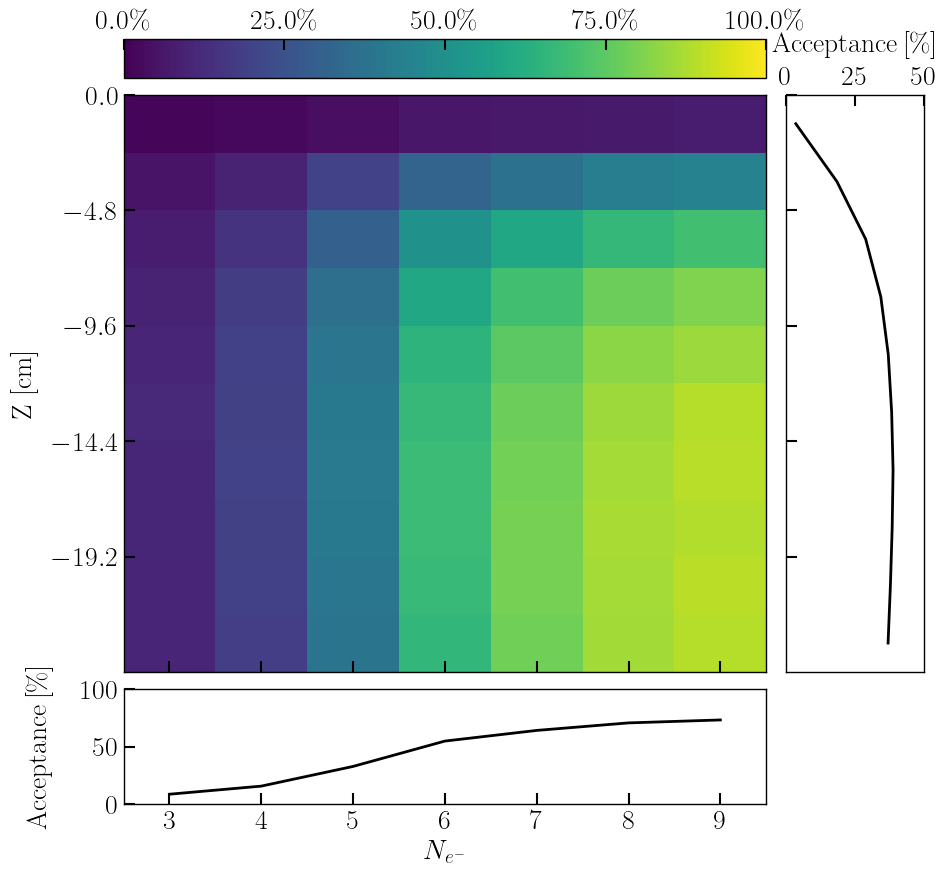

In [23]:
from matplotlib import colors

e_bins = np.arange(3,10,1)

norm = colors.Normalize(vmin=0, vmax=100)
fig = plt.figure(figsize=(10,9))
plt.style.use('../relics.mplstyle') 
gs = matplotlib.gridspec.GridSpec(3,2, height_ratios=[0.05,0.75,0.15], width_ratios=[0.7,0.15])
gs.update(left=0.15, right=0.95, bottom=0.08, top=0.93, wspace=0.05, hspace=0.07)

ax1 = plt.subplot(gs[1,0])
mesh = ax1.pcolormesh(e_bins,z_bins, ratio_roi.T[::-1, :] * 100,norm = norm)

# 设置 x 和 y 轴
# ax1.set_yticks(np.arange(0, 240, 48))
ax1.set_ylabel(r'$\mathrm{Z\ [cm]}$', labelpad=10)
ax1.set_yticks(np.arange(48, 288, 48))
ax1.set_yticklabels([r'${}\mathrm{{}}$'.format(i) for i in np.arange(-192, 48, 48)/10])
ax1.set_xticklabels([r'${}$'])
ax1.set_xlim([2.5,9.5])

cbax = plt.subplot(gs[0,0])
# 为 colorbar 创建 colorbar
cbar = plt.colorbar(mappable=mesh, cax=cbax, orientation='horizontal', ticklocation='top')
cbar.set_ticks([0, 25, 50, 75, 100])
cbar.set_ticklabels([r'${}\%$'.format(i) for i in np.arange(0, 1.25, 0.25)*100])

ax1v = plt.subplot(gs[1,1])
ax1v.plot((ratio_z_roi * 100)[::-1],np.arange(0, 240, 24)+12,color='k',)
# ax1v.set_ylabel(r'$\mathrm{}$')
ax1v.set_xlabel(r'$\mathrm{Acceptance\left [ \% \right ] }$', labelpad=10)
ax1v.set_xticks(np.arange(0,75,25))
ax1v.set_xticklabels([r'${}\mathrm{{}}$'.format(i) for i in np.arange(0,75,25)])
ax1v.set_yticks(np.arange(48, 288, 48))
ax1v.set_yticklabels([])
ax1v.set_xlim([0,50])
ax1v.set_ylim([0,240])
ax1v.xaxis.tick_top()
ax1v.xaxis.set_label_position('top')

ax1h = plt.subplot(gs[2,0])
ax1h.plot(e_bins,ratio_e_roi * 100,color='k',)
ax1h.set_xlim([2.5,9.5])
ax1h.set_ylim([0,100])
ax1h.set_xticks(e_bins)
ax1h.set_xticklabels([])
ax1h.set_yticks(np.arange(0,150,50))
ax1h.set_yticklabels([r'${}\mathrm{{}}$'.format(i) for i in np.arange(0,150,50)])
ax1h.set_ylabel(r'$\mathrm{Acceptance\left [ \% \right ] }$', labelpad=20)
ax1h.set_xticklabels([r'${}$'.format(i) for i in e_bins])
ax1h.set_xlabel(r'$N_{e^{-}}$')



cbax.tick_params(direction='in')
ax1.tick_params(direction='in')
ax1v.tick_params(direction='in')
ax1h.tick_params(direction='in')
# plt.tight_layout()
plt.plot()
plt.savefig("Acceptance.pdf")
plt.show()



In [32]:
ratio_e_roi

array([0.08807451, 0.15816423, 0.32882983, 0.54858427, 0.64094367,
       0.70614694, 0.73163086])

In [24]:
8 * (6)**0.5

19.595917942265423

In [25]:
e_spectrum = np.array([1021.5997675574218,474.2178801236556,222.03279893822705,104.35334139728404,50.258124794689884]) * 0.73
e_num_roi = e_spectrum * ratio_roi_area[:5]
e_num_cut = e_num_roi * ratio_e_roi[:5]

In [26]:
e_spectrum

array([745.76783032, 346.17905249, 162.08394322,  76.17793922,
        36.6884311 ])

In [27]:
30 ** 0.5

5.477225575051661

In [28]:
e_num_roi,ratio_e_roi[:5],e_num_cut,np.sum(e_num_cut) * 32

(array([ 11.41546818, 172.89843541, 154.49760426,  75.68301115,
         30.36125434]),
 array([0.08807451, 0.15816423, 0.32882983, 0.54858427, 0.64094367]),
 array([ 1.0054118 , 27.34634826, 50.80342019, 41.51850957, 19.45985371]),
 4484.273392952367)

In [29]:
ratio_e_roi

array([0.08807451, 0.15816423, 0.32882983, 0.54858427, 0.64094367,
       0.70614694, 0.73163086])

In [30]:
np.sum(np.array([474.2178801236556,222.03279893822705,104.35334139728404,50.258124794689884])) * 32

27227.588648123412

In [31]:
ratio_e_roi[:5]* ratio_roi_area[:5] * np.array([1021.5997675574218,474.2178801236556,222.03279893822705,104.35334139728404,50.258124794689884])

array([ 1.37727644, 37.46075104, 69.59372628, 56.87467065, 26.65733385])

In [32]:
ratio_roi_area[:5] * np.array([1021.5997675574218,474.2178801236556,222.03279893822705,104.35334139728404,50.258124794689884])

array([ 15.48540928, 237.42571761, 211.66719772, 103.68683661,
        41.59628776])

In [33]:
ratio_e_roi[:5]* ratio_roi_area[:5]

array([0.00133272, 0.07924709, 0.3134039 , 0.54501366, 0.53040251])

In [34]:
np.sum(ratio_e_roi[:5]* ratio_roi_area[:5] * np.array([1021.5997675574218,474.2178801236556,222.03279893822705,104.35334139728404,50.258124794689884])) * 32

6145.88376269995

In [35]:
ratio_roi

array([[0.01331602, 0.05369614, 0.07936514, 0.09537966, 0.10389532,
        0.11138832, 0.10756391, 0.10644054, 0.10434917, 0.10382375],
       [0.02089314, 0.09430095, 0.14666905, 0.17696482, 0.19018609,
        0.19447004, 0.19632301, 0.1921023 , 0.18804583, 0.18287182],
       [0.03900512, 0.19642669, 0.30408554, 0.36252229, 0.39039285,
        0.40487683, 0.40920623, 0.40378992, 0.39388585, 0.38332544],
       [0.05992696, 0.31875139, 0.50297764, 0.59513884, 0.64609461,
        0.66830676, 0.6806494 , 0.68077213, 0.67365366, 0.65889896],
       [0.0642997 , 0.373214  , 0.5947525 , 0.69768207, 0.74939844,
        0.77464836, 0.78879414, 0.79278621, 0.78966219, 0.78327553],
       [0.06756249, 0.41795902, 0.66528658, 0.77378138, 0.82672383,
        0.85163809, 0.86339069, 0.86896301, 0.86454282, 0.86067475],
       [0.07423329, 0.44042075, 0.69586417, 0.80590229, 0.84904131,
        0.88789948, 0.89262197, 0.88488049, 0.8958174 , 0.88691418]])

In [36]:
ratio_roi.shape

(7, 10)

TypeError: Dimensions of C (7, 10) should be one smaller than X(10) and Y(5) while using shading='flat' see help(pcolormesh)

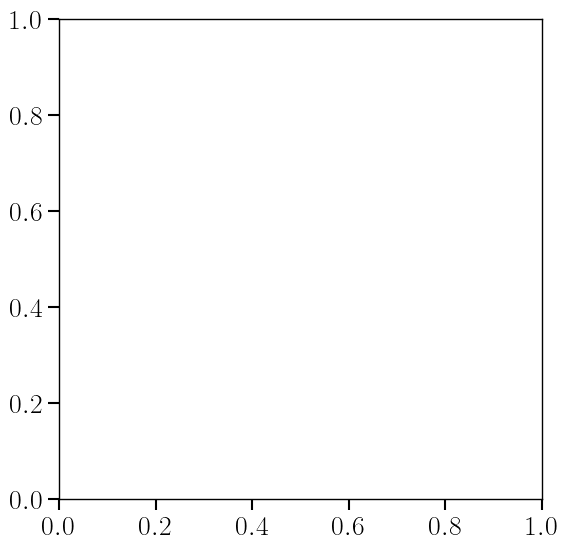

In [37]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

e_bins = np.arange(3,8,1)
z_bins = np.arange(0, 240, 24) + 12
norm = colors.Normalize(vmin=0, vmax=1)
fig = plt.figure(figsize=(8,8))

# 使用gridspec分割figure
gs = gridspec.GridSpec(2, 2, width_ratios=[6, 1], height_ratios=[6,1]) 

# 主图
ax1 = plt.subplot(gs[0, 0])
# image = ax1.imshow(ratio_roi, norm = norm)
ax1.pcolormesh(z_bins, e_bins, ratio_roi,norm = norm)

# 为 colorbar 创建一个新的 axes 对象
divider = make_axes_locatable(ax1)
cax = divider.append_axes("top", size="10%", pad=0.1)

# 为 colorbar 创建 colorbar
cbar = plt.colorbar(image, cax=cax, orientation='horizontal', ticklocation='top')
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.set_ticklabels([r'${}$'.format(i) for i in np.arange(0, 1.25, 0.25)])

# 设置 x 和 y 轴
ax1.set_xticks(np.arange(0, 288, 48))
ax1.set_xticklabels([r'${}\mathrm{{}}$'.format(i) for i in np.arange(0, 288, 48)])
ax1.set_yticks(np.arange(3, 9, 2))
ax1.set_yticklabels([r'${}\mathrm{{e}}$'.format(i) for i in np.arange(3, 9, 2)])
ax1.set_ylabel(r'$\mathrm{Num\ of\ e}$')
ax1.set_ylim([2.5,7.5])

# 底部子图
ax2 = plt.subplot(gs[1, 0], sharex=ax1)
ax2.plot(np.arange(10),ratio_z_roi)
ax2.set_xlabel(r'$\mathrm{Z\ [cm]}$')

# 右侧子图
ax3 = plt.subplot(gs[0, 1], sharey=ax1)
ax3.plot(ratio_e_roi,np.arange(5))


# 显示图像
plt.show()

类型定义
====

In [2]:
import torch
import torch.nn as nn
import pickle
from PIL import Image
import h5py

#神经网络的结构，得跑一下才能把后面有些定义的变量弄进去，不耗时间
class WaveformClassifier(nn.Module):
    def __init__(self):
        super(WaveformClassifier, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)  # 使用全局平均池化层
        self.fc = nn.Sequential(
            nn.Linear(128, 64),  # 修改全连接层的输入维度
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 2)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.global_pool(x).squeeze(2)
        x = self.fc(x)
        return x
    

In [ ]:
# 转换数据通道数为1并调整大小
test_cevns_data = waveform_list.reshape(-1, 1, 3500)
test_cevns_labels = np.ones(len(test_cevns_data))
test_cevns_pe = np.sum(np.sum(test_cevns_data,axis = 1),axis = 1)

test_data = test_cevns_data
test_labels = test_cevns_labels
test_pe = test_cevns_pe


# 将测试集数据和标签转换为PyTorch张量
test_data = torch.from_numpy(test_data).float()
test_labels = torch.from_numpy(test_labels).long()

# 创建测试集数据集和数据加载器
test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# 加载模型
model = WaveformClassifier()
model.load_state_dict(torch.load('../waveform_classifier.pth'))


# 测试模式
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0
test_confusion_matrix = torch.zeros(2, 2)
criterion = nn.CrossEntropyLoss()

num_epochs = 2
with torch.no_grad():
    for batch_data, batch_labels in test_dataloader:
        outputs = model(batch_data)
        loss = criterion(outputs, batch_labels)
        test_loss += loss.item() * batch_data.size(0)

        # 计算测试集准确率和混淆矩阵
        _, predicted = torch.max(outputs, 1)
        test_total += batch_labels.size(0)
        test_correct += (predicted == batch_labels).sum().item()

        for i in range(len(predicted)):
            test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

# 计算平均测试集损失函数和准确率
test_loss /= len(test_dataset)
test_accuracy = test_correct / test_total

# 计算标签0判断为标签1和标签1判断为标签0的概率
test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


# 在测试集上进行评估
model.eval()
test_confusion_matrix = torch.zeros(2, 2)

# 在测试集上计算预测分数
with torch.no_grad():
    model.eval()
    outputs = model(test_data)
    scores = torch.softmax(outputs, dim=1)

# 绘制预测分数的分布
scores_label_0 = scores[test_labels == 0]
scores_label_1 = scores[test_labels == 1]

score = scores_label_1[:, 0].numpy()
mask_wf = (score > 0.8)
mask_width = (test_cevns_std * 1e6 > 0.22)

In [38]:
acceptance_pattern =  len(score[mask_wf]) / len(score)
acceptance_wf_width = len(score[mask_wf * mask_width]) / len(score)
acceptance_wf_width,acceptance_pattern

NameError: name 'score' is not defined

模拟数据读取
====

In [13]:
def list_files(start_path, prefix):
    file_list = []
    for file in os.listdir(start_path):
        if file.startswith(prefix):
            # print(os.path.join(start_path, file))
            file_list.append(os.path.join(start_path, file))
    return file_list

# 调用函数，替换 'path_to_directory' 和 'prefix' 为你需要的路径和前缀
file_list_3 = list_files('waveform_result_0824/', 'wf_pass_pattern_cevns_3')
file_list_4 = list_files('waveform_result_0824/', 'wf_pass_pattern_cevns_4')
file_list_5 = list_files('waveform_result_0824/', 'wf_pass_pattern_cevns_5')
file_list_6 = list_files('waveform_result_0824/', 'wf_pass_pattern_cevns_6')
file_list_7 = list_files('waveform_result_0824/', 'wf_pass_pattern_cevns_7')
file_list_8 = list_files('waveform_result_0824/', 'wf_pass_pattern_cevns_8')
file_list_9 = list_files('waveform_result_0824/', 'wf_pass_pattern_cevns_9')
file_list_10 = list_files('waveform_result_0824/', 'wf_pass_pattern_cevns_10')

In [14]:
len(file_list_3), len(file_list_4), 
len(file_list_5), len(file_list_6),
len(file_list_7), len(file_list_8),
len(file_list_9), len(file_list_10),

(93, 95)

In [111]:
pe_bins = np.arange(90,310,10)
z_bins = np.linspace(0,240,11)
len(pe_bins)

22

In [114]:
def acceptance_get(file_path):
    pe_bins = np.arange(90,310,10)
    z_bins = np.linspace(0,240,11)
    hist_after_cumulate = np.zeros((len(z_bins)-1, len(pe_bins)-1))
    hist_before_cumulate = np.zeros((len(z_bins)-1, len(pe_bins)-1))
    file_list = file_path
    for i in tqdm(range(len(file_list))):
        file = np.load(file_list[i])
        z_list = file['z_pass_pattern'] * 10
        waveform_list = file['wf_pass_pattern']
        waveform_std = file['wf_std_pass_pattern']
        area_cevns = file['area_cevns']
        z_cevns = np.linspace(0, 240, len(area_cevns))
        # 转换数据通道数为1并调整大小
        test_cevns_data = waveform_list.reshape(-1, 1, 3500)
        test_cevns_labels = np.ones(len(test_cevns_data))
        test_cevns_pe = np.sum(np.sum(test_cevns_data,axis = 1),axis = 1)

        test_data = test_cevns_data
        test_labels = test_cevns_labels
        test_pe = test_cevns_pe


        # 将测试集数据和标签转换为PyTorch张量
        test_data = torch.from_numpy(test_data).float()
        test_labels = torch.from_numpy(test_labels).long()

        # 创建测试集数据集和数据加载器
        test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
        test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

        # 加载模型
        model = WaveformClassifier()
        model.load_state_dict(torch.load('../waveform_classifier.pth'))


        # 测试模式
        model.eval()

        test_loss = 0.0
        test_correct = 0
        test_total = 0
        test_confusion_matrix = torch.zeros(2, 2)
        criterion = nn.CrossEntropyLoss()

        num_epochs = 2
        with torch.no_grad():
            for batch_data, batch_labels in test_dataloader:
                outputs = model(batch_data)
                loss = criterion(outputs, batch_labels)
                test_loss += loss.item() * batch_data.size(0)

                # 计算测试集准确率和混淆矩阵
                _, predicted = torch.max(outputs, 1)
                test_total += batch_labels.size(0)
                test_correct += (predicted == batch_labels).sum().item()

                for i in range(len(predicted)):
                    test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

        # 计算平均测试集损失函数和准确率
        test_loss /= len(test_dataset)
        test_accuracy = test_correct / test_total

        # 计算标签0判断为标签1和标签1判断为标签0的概率
        test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
        test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

        # print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
        # print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


        # 在测试集上进行评估
        model.eval()
        test_confusion_matrix = torch.zeros(2, 2)

        # 在测试集上计算预测分数
        with torch.no_grad():
            model.eval()
            outputs = model(test_data)
            scores = torch.softmax(outputs, dim=1)

        # 绘制预测分数的分布
        scores_label_0 = scores[test_labels == 0]
        scores_label_1 = scores[test_labels == 1]

        score = scores_label_1[:, 0].numpy()
        mask_wf = (score > 0.8)
        mask_width = (waveform_std * 1e6 > 0.22)
        z_after_cut = z_list[mask_wf * mask_width]
        pe_after_cut = np.sum(waveform_list[mask_wf * mask_width],axis = 1)
        z_original = z_cevns
        pe_original = area_cevns
        hist_after, xedges, yedges = np.histogram2d(z_after_cut, pe_after_cut, bins=(z_bins, pe_bins))
        hist_before, xedges, yedges = np.histogram2d(z_original, pe_original, bins=(z_bins, pe_bins))
        hist_after_cumulate += hist_after
        hist_before_cumulate += hist_before

    valid_mask = hist_before_cumulate > len(file_list)*len(area_cevns) * 0.0001
    ratio = np.zeros(hist_before_cumulate.shape)
    ratio[valid_mask] = hist_after_cumulate[valid_mask] / hist_before_cumulate[valid_mask]
    average_roi = np.sum(hist_after_cumulate) / np.sum(hist_before_cumulate)
    average_z = np.sum(hist_after_cumulate[:,3:],axis = 1) / np.sum(hist_before_cumulate[:,3:],axis = 1)
    return ratio, average_roi, average_z, hist_after_cumulate, hist_before_cumulate

3电子
====

In [115]:
ratio_3, average_roi_3, average_z_3, hist_after_cumulate_3, hist_before_cumulate_3 = acceptance_get(file_list_3[:20])
ratio_4, average_roi_4, average_z_4, hist_after_cumulate_4, hist_before_cumulate_4 = acceptance_get(file_list_4[:20])
ratio_5, average_roi_5, average_z_5, hist_after_cumulate_5, hist_before_cumulate_5 = acceptance_get(file_list_5[:20])
ratio_6, average_roi_6, average_z_6, hist_after_cumulate_6, hist_before_cumulate_6 = acceptance_get(file_list_6[:20])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [02:07<00:00,  6.37s/it]


In [116]:
ratio_7, average_roi_7, average_z_7, hist_after_cumulate_7, hist_before_cumulate_7 = acceptance_get(file_list_7[:10])
ratio_8, average_roi_8, average_z_8, hist_after_cumulate_8, hist_before_cumulate_8 = acceptance_get(file_list_8[:10])
ratio_9, average_roi_9, average_z_9, hist_after_cumulate_9, hist_before_cumulate_9 = acceptance_get(file_list_9[:10])
ratio_10, average_roi_10, average_z_10, hist_after_cumulate_10, hist_before_cumulate_10 = acceptance_get(file_list_10[:10])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:25<00:00,  8.57s/it]


In [117]:
ratio_roi = np.array([average_z_3,average_z_4,
                      average_z_5,average_z_6,
                      average_z_7,average_z_8,
                      average_z_9,average_z_10,])

In [3]:
import numpy as np
result = np.load("acceptqance_roi_300.npz")
result['ratio_3'].shape

(10, 21)

In [5]:
pe_bins = np.arange(90,310,10)
pe_bins.shape,pe_bins

((22,),
 array([ 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210,
        220, 230, 240, 250, 260, 270, 280, 290, 300]))

In [118]:
np.savez("acceptqance_roi_300.npz", 
         ratio_3 = ratio_3,
         ratio_4 = ratio_4,
         ratio_5 = ratio_5,
         ratio_6 = ratio_6,
         ratio_7 = ratio_7,
         ratio_8 = ratio_8,
         ratio_9 = ratio_9,
         ratio_10 = ratio_10,
        )
np.savez("acceptqance_roi_300_z.npz",
         ratio_roi = ratio_roi
        )

In [126]:
data_original = np.load("e_spectrum_relics.npz")
cevns_num = data_original['CEvNS']
e_weight= np.sum(np.sum(np.array([hist_before_cumulate_3[:,3:],
                           hist_before_cumulate_4[:,3:],
                           hist_before_cumulate_5[:,3:],
                           hist_before_cumulate_6[:,3:],
                           hist_before_cumulate_7[:,3:],
                           hist_before_cumulate_8[:,3:],
                           hist_before_cumulate_9[:,3:],
                           hist_before_cumulate_10[:,3:],
                          ]),axis = 1),axis = 1) / np.array([20,20,20,20,10,10,10,10])
ratio_z_roi = np.average(ratio_roi,axis = 0,weights = cevns_num[3:11] * e_weight)
ratio_e_roi = np.average(ratio_roi,axis = 1)

In [127]:
e_weight

array([ 692.4 , 5696.  , 9395.15, 9970.65, 9977.6 , 9582.4 , 7496.2 ,
       3820.5 ])

In [128]:
cevns_num[3:11] * e_weight

array([ 491206.34735877, 1742846.30132874, 1303779.47156193,
        633099.52503444,  286703.00630073,  121947.16202589,
         41092.73627695,    8740.14742193])

In [129]:
ratio_z_roi

array([0.04015645, 0.20326576, 0.31529764, 0.37409155, 0.40454279,
       0.41741655, 0.42523821, 0.42193639, 0.41962873, 0.4124325 ])

/tmp/ipykernel_1885056/1400666697.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels([r'${}$'])


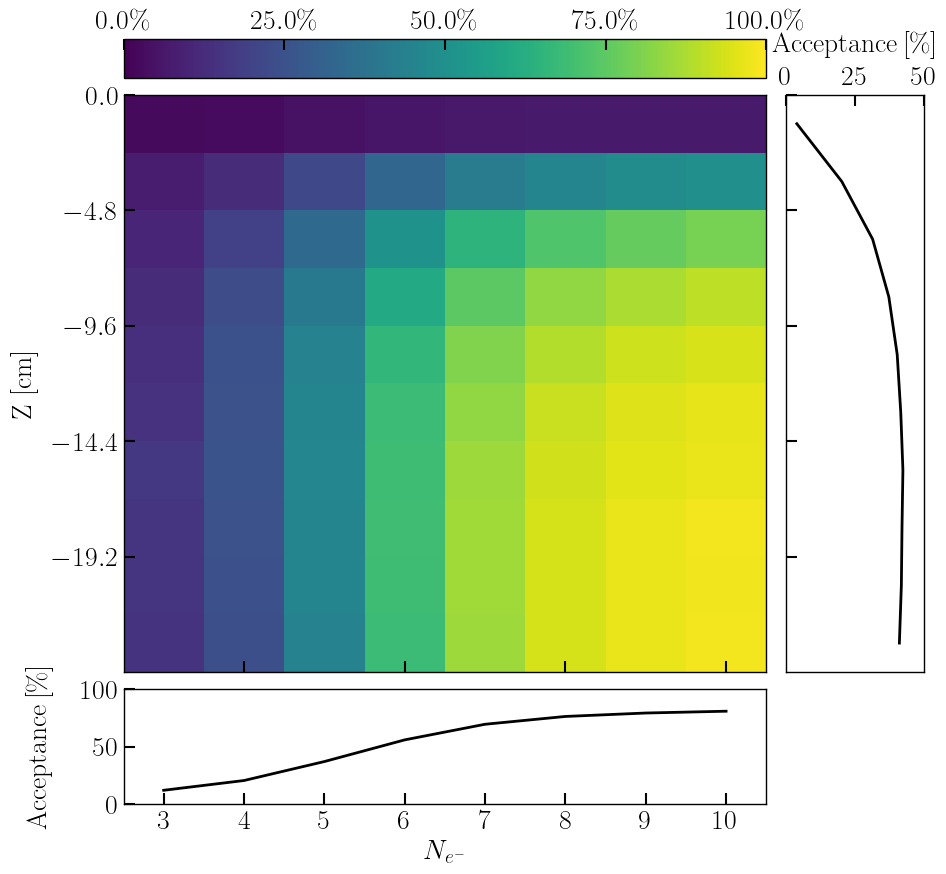

In [130]:
from matplotlib import colors

# e_bins = np.arange(2.5,11.5,1)
e_bins = np.arange(3,11,1)
z_bins = np.arange(0, 240, 24) + 12
E_bins,Z_bins = np.meshgrid(e_bins, z_bins)

norm = colors.Normalize(vmin=0, vmax=100)
fig = plt.figure(figsize=(10,9))
plt.style.use('../relics.mplstyle') 
gs = matplotlib.gridspec.GridSpec(3,2, height_ratios=[0.05,0.75,0.15], width_ratios=[0.7,0.15])
gs.update(left=0.15, right=0.95, bottom=0.08, top=0.93, wspace=0.05, hspace=0.07)

ax1 = plt.subplot(gs[1,0])
mesh = ax1.pcolormesh(E_bins,Z_bins, ratio_roi.T[::-1, :]* 100,norm = norm)

# 设置 x 和 y 轴
# ax1.set_yticks(np.arange(0, 240, 48))
ax1.set_ylabel(r'$\mathrm{Z\ [cm]}$', labelpad=10)
ax1.set_yticks(np.arange(48, 288, 48))
ax1.set_yticklabels([r'${}\mathrm{{}}$'.format(i) for i in np.arange(-192, 48, 48)/10])
ax1.set_xticklabels([r'${}$'])
ax1.set_xlim([2.5,10.5])

cbax = plt.subplot(gs[0,0])
# 为 colorbar 创建 colorbar
cbar = plt.colorbar(mappable=mesh, cax=cbax, orientation='horizontal', ticklocation='top')
cbar.set_ticks([0, 25, 50, 75, 100])
cbar.set_ticklabels([r'${}\%$'.format(i) for i in np.arange(0, 1.25, 0.25)*100])

ax1v = plt.subplot(gs[1,1])
ax1v.plot((ratio_z_roi * 100)[::-1],np.arange(0, 240, 24)+12,color='k',)
# ax1v.set_ylabel(r'$\mathrm{}$')
ax1v.set_xlabel(r'$\mathrm{Acceptance\left [ \% \right ] }$', labelpad=10)
ax1v.set_xticks(np.arange(0,75,25))
ax1v.set_xticklabels([r'${}\mathrm{{}}$'.format(i) for i in np.arange(0,75,25)])
ax1v.set_yticks(np.arange(48, 288, 48))
ax1v.set_yticklabels([])
ax1v.set_xlim([0,50])
ax1v.set_ylim([0,240])
ax1v.xaxis.tick_top()
ax1v.xaxis.set_label_position('top')

ax1h = plt.subplot(gs[2,0])
ax1h.plot(e_bins,ratio_e_roi * 100,color='k',)
ax1h.set_xlim([2.5,10.5])
ax1h.set_ylim([0,100])
ax1h.set_xticks(e_bins)
# ax1h.set_xticklabels([r'${}\mathrm{{}}$'.format(i) for i in e_bins])
ax1h.set_yticks(np.arange(0,150,50))
ax1h.set_yticklabels([r'${}\mathrm{{}}$'.format(i) for i in np.arange(0,150,50)])
ax1h.set_ylabel(r'$\mathrm{Acceptance\left [ \% \right ] }$', labelpad=20)
ax1h.set_xlabel(r'$N_{e^{-}}$')



cbax.tick_params(direction='in')
ax1.tick_params(direction='in')
ax1v.tick_params(direction='in')
ax1h.tick_params(direction='in')
# plt.tight_layout()
plt.plot()
plt.savefig("Acceptance_300.pdf")
plt.show()



In [13]:
# hist_after_cumulate = np.zeros((len(z_bins)-1, len(pe_bins)-1))
# hist_before_cumulate = np.zeros((len(z_bins)-1, len(pe_bins)-1))
# file_list = file_list_3
# for i in tqdm(range(len(file_list))):
#     file = np.load(file_list[i])
#     z_list = file['z_pass_pattern'] * 10
#     waveform_list = file['wf_pass_pattern']
#     waveform_std = file['wf_std_pass_pattern']
#     area_cevns = file['area_cevns']
#     z_cevns = np.linspace(0, 240, len(area_cevns))
#     # 转换数据通道数为1并调整大小
#     test_cevns_data = waveform_list.reshape(-1, 1, 3500)
#     test_cevns_labels = np.ones(len(test_cevns_data))
#     test_cevns_pe = np.sum(np.sum(test_cevns_data,axis = 1),axis = 1)

#     test_data = test_cevns_data
#     test_labels = test_cevns_labels
#     test_pe = test_cevns_pe


#     # 将测试集数据和标签转换为PyTorch张量
#     test_data = torch.from_numpy(test_data).float()
#     test_labels = torch.from_numpy(test_labels).long()

#     # 创建测试集数据集和数据加载器
#     test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
#     test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

#     # 加载模型
#     model = WaveformClassifier()
#     model.load_state_dict(torch.load('../waveform_classifier.pth'))


#     # 测试模式
#     model.eval()

#     test_loss = 0.0
#     test_correct = 0
#     test_total = 0
#     test_confusion_matrix = torch.zeros(2, 2)
#     criterion = nn.CrossEntropyLoss()

#     num_epochs = 2
#     with torch.no_grad():
#         for batch_data, batch_labels in test_dataloader:
#             outputs = model(batch_data)
#             loss = criterion(outputs, batch_labels)
#             test_loss += loss.item() * batch_data.size(0)

#             # 计算测试集准确率和混淆矩阵
#             _, predicted = torch.max(outputs, 1)
#             test_total += batch_labels.size(0)
#             test_correct += (predicted == batch_labels).sum().item()

#             for i in range(len(predicted)):
#                 test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

#     # 计算平均测试集损失函数和准确率
#     test_loss /= len(test_dataset)
#     test_accuracy = test_correct / test_total

#     # 计算标签0判断为标签1和标签1判断为标签0的概率
#     test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
#     test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

#     # print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
#     # print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


#     # 在测试集上进行评估
#     model.eval()
#     test_confusion_matrix = torch.zeros(2, 2)

#     # 在测试集上计算预测分数
#     with torch.no_grad():
#         model.eval()
#         outputs = model(test_data)
#         scores = torch.softmax(outputs, dim=1)

#     # 绘制预测分数的分布
#     scores_label_0 = scores[test_labels == 0]
#     scores_label_1 = scores[test_labels == 1]

#     score = scores_label_1[:, 0].numpy()
#     mask_wf = (score > 0.8)
#     mask_width = (waveform_std * 1e6 > 0.22)
#     z_after_cut = z_list[mask_wf * mask_width]
#     pe_after_cut = np.sum(waveform_list[mask_wf * mask_width],axis = 1)
#     z_original = z_cevns
#     pe_original = area_cevns
#     hist_after, xedges, yedges = np.histogram2d(z_after_cut, pe_after_cut, bins=(z_bins, pe_bins))
#     hist_before, xedges, yedges = np.histogram2d(z_original, pe_original, bins=(z_bins, pe_bins))
#     hist_after_cumulate += hist_after
#     hist_before_cumulate += hist_before

# valid_mask = hist_before_cumulate > len(file_list)*len(area_cevns) * 0.0001
# ratio_3 = np.zeros(hist_before_cumulate.shape)
# ratio_3[valid_mask] = hist_after_cumulate[valid_mask] / hist_before_cumulate[valid_mask]

# average_3_roi = np.sum(hist_after_cumulate) / np.sum(hist_before_cumulate)

4电子
====

In [15]:
ratio_4, average_roi_4 = acceptance_get(file_list_4)

100%|██████████████████████████████████████████████████████████████████████████████████████████| 28/28 [01:07<00:00,  2.41s/it]


In [16]:
ratio_4, average_roi_4

(array([[0.00389294, 0.00628415, 0.00922583, 0.01593323, 0.02675076,
         0.03329024, 0.03090508, 0.05064782, 0.0798722 , 0.06315789,
         0.0625    , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.0190709 , 0.02818399, 0.05262097, 0.07291475, 0.10694475,
         0.13390501, 0.17853042, 0.21382008, 0.25153374, 0.375     ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.02478929, 0.04026316, 0.07265962, 0.12608948, 0.16472868,
         0.23661599, 0.29268293, 0.31751825, 0.38081395, 0.46511628,
         0.3125    , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.02104256, 0.04477212, 0.08702532, 0.13964299, 0.20322154,
         0.28288232, 0.37916153, 0.41145833, 0.44404332, 0.53488372,
         0.        , 0.        

In [13]:
hist_after_cumulate = np.zeros((10, 14))
hist_before_cumulate = np.zeros((10, 14))
file_list = file_list_4
for i in tqdm(range(len(file_list[:10]))):
    file = np.load(file_list[i])
    z_list = file['z_pass_pattern'] * 10
    waveform_list = file['wf_pass_pattern']
    waveform_std = file['wf_std_pass_pattern']
    area_cevns = file['area_cevns']
    z_cevns = np.linspace(0, 240, len(area_cevns))
    # 转换数据通道数为1并调整大小
    test_cevns_data = waveform_list.reshape(-1, 1, 3500)
    test_cevns_labels = np.ones(len(test_cevns_data))
    test_cevns_pe = np.sum(np.sum(test_cevns_data,axis = 1),axis = 1)

    test_data = test_cevns_data
    test_labels = test_cevns_labels
    test_pe = test_cevns_pe


    # 将测试集数据和标签转换为PyTorch张量
    test_data = torch.from_numpy(test_data).float()
    test_labels = torch.from_numpy(test_labels).long()

    # 创建测试集数据集和数据加载器
    test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 加载模型
    model = WaveformClassifier()
    model.load_state_dict(torch.load('../waveform_classifier.pth'))


    # 测试模式
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0
    test_confusion_matrix = torch.zeros(2, 2)
    criterion = nn.CrossEntropyLoss()

    num_epochs = 2
    with torch.no_grad():
        for batch_data, batch_labels in test_dataloader:
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            test_loss += loss.item() * batch_data.size(0)

            # 计算测试集准确率和混淆矩阵
            _, predicted = torch.max(outputs, 1)
            test_total += batch_labels.size(0)
            test_correct += (predicted == batch_labels).sum().item()

            for i in range(len(predicted)):
                test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

    # 计算平均测试集损失函数和准确率
    test_loss /= len(test_dataset)
    test_accuracy = test_correct / test_total

    # 计算标签0判断为标签1和标签1判断为标签0的概率
    test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
    test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

    # print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
    # print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


    # 在测试集上进行评估
    model.eval()
    test_confusion_matrix = torch.zeros(2, 2)

    # 在测试集上计算预测分数
    with torch.no_grad():
        model.eval()
        outputs = model(test_data)
        scores = torch.softmax(outputs, dim=1)

    # 绘制预测分数的分布
    scores_label_0 = scores[test_labels == 0]
    scores_label_1 = scores[test_labels == 1]

    score = scores_label_1[:, 0].numpy()
    mask_wf = (score > 0.8)
    mask_width = (waveform_std * 1e6 > 0.22)
    z_after_cut = z_list[mask_wf * mask_width]
    pe_after_cut = np.sum(waveform_list[mask_wf * mask_width],axis = 1)
    z_original = z_cevns
    pe_original = area_cevns
    hist_after, xedges, yedges = np.histogram2d(z_after_cut, pe_after_cut, bins=(z_bins, pe_bins))
    hist_before, xedges, yedges = np.histogram2d(z_original, pe_original, bins=(z_bins, pe_bins))
    hist_after_cumulate += hist_after
    hist_before_cumulate += hist_before

valid_mask = hist_before_cumulate > len(file_list)*len(area_cevns) * 0.0001
ratio_4 = np.zeros(hist_before_cumulate.shape)
ratio_4[valid_mask] = hist_after_cumulate[valid_mask] / hist_before_cumulate[valid_mask]

average_4_roi = np.sum(hist_after_cumulate) / np.sum(hist_before_cumulate)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [03:26<00:00, 20.66s/it]


In [14]:
ratio_4

array([[0.00270966, 0.00513712, 0.00985749, 0.01549464, 0.02191458,
        0.02675136, 0.04026953, 0.04989677, 0.06181818, 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.01129559, 0.02136171, 0.04164347, 0.06510825, 0.09804649,
        0.14059282, 0.17679291, 0.20815451, 0.26497278, 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.01434644, 0.03304576, 0.05959933, 0.09965671, 0.15584335,
        0.21220327, 0.28576078, 0.33415061, 0.41809955, 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.01693794, 0.03338052, 0.06953513, 0.11848117, 0.18607114,
        0.2636915 , 0.34788914, 0.42457123, 0.45676692, 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.01640005, 0.03622468, 0.07291263, 0.12804024, 0.1988487 ,
        0.2847789 , 0.3709598 , 0.45005221, 0.51067616, 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.0136876 , 0.03596074, 0.0

5电子
====

In [15]:
hist_after_cumulate = np.zeros((10, 14))
hist_before_cumulate = np.zeros((10, 14))
file_list = file_list_5
for i in tqdm(range(len(file_list[:10]))):
    file = np.load(file_list[i])
    z_list = file['z_pass_pattern'] * 10
    waveform_list = file['wf_pass_pattern']
    waveform_std = file['wf_std_pass_pattern']
    area_cevns = file['area_cevns']
    z_cevns = np.linspace(0, 240, len(area_cevns))
    # 转换数据通道数为1并调整大小
    test_cevns_data = waveform_list.reshape(-1, 1, 3500)
    test_cevns_labels = np.ones(len(test_cevns_data))
    test_cevns_pe = np.sum(np.sum(test_cevns_data,axis = 1),axis = 1)

    test_data = test_cevns_data
    test_labels = test_cevns_labels
    test_pe = test_cevns_pe


    # 将测试集数据和标签转换为PyTorch张量
    test_data = torch.from_numpy(test_data).float()
    test_labels = torch.from_numpy(test_labels).long()

    # 创建测试集数据集和数据加载器
    test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 加载模型
    model = WaveformClassifier()
    model.load_state_dict(torch.load('../waveform_classifier.pth'))


    # 测试模式
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0
    test_confusion_matrix = torch.zeros(2, 2)
    criterion = nn.CrossEntropyLoss()

    num_epochs = 2
    with torch.no_grad():
        for batch_data, batch_labels in test_dataloader:
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            test_loss += loss.item() * batch_data.size(0)

            # 计算测试集准确率和混淆矩阵
            _, predicted = torch.max(outputs, 1)
            test_total += batch_labels.size(0)
            test_correct += (predicted == batch_labels).sum().item()

            for i in range(len(predicted)):
                test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

    # 计算平均测试集损失函数和准确率
    test_loss /= len(test_dataset)
    test_accuracy = test_correct / test_total

    # 计算标签0判断为标签1和标签1判断为标签0的概率
    test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
    test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

    # print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
    # print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


    # 在测试集上进行评估
    model.eval()
    test_confusion_matrix = torch.zeros(2, 2)

    # 在测试集上计算预测分数
    with torch.no_grad():
        model.eval()
        outputs = model(test_data)
        scores = torch.softmax(outputs, dim=1)

    # 绘制预测分数的分布
    scores_label_0 = scores[test_labels == 0]
    scores_label_1 = scores[test_labels == 1]

    score = scores_label_1[:, 0].numpy()
    mask_wf = (score > 0.8)
    mask_width = (waveform_std * 1e6 > 0.22)
    z_after_cut = z_list[mask_wf * mask_width]
    pe_after_cut = np.sum(waveform_list[mask_wf * mask_width],axis = 1)
    z_original = z_cevns
    pe_original = area_cevns
    hist_after, xedges, yedges = np.histogram2d(z_after_cut, pe_after_cut, bins=(z_bins, pe_bins))
    hist_before, xedges, yedges = np.histogram2d(z_original, pe_original, bins=(z_bins, pe_bins))
    hist_after_cumulate += hist_after
    hist_before_cumulate += hist_before

valid_mask = hist_before_cumulate > len(file_list)*len(area_cevns) * 0.0001
ratio_5 = np.zeros(hist_before_cumulate.shape)
ratio_5[valid_mask] = hist_after_cumulate[valid_mask] / hist_before_cumulate[valid_mask]

average_5_roi = np.sum(hist_after_cumulate) / np.sum(hist_before_cumulate)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:40<00:00, 46.06s/it]


In [16]:
ratio_5

array([[0.00205761, 0.00507937, 0.00685835, 0.01732385, 0.02512482,
        0.0348125 , 0.04038171, 0.04989645, 0.06068929, 0.06039894,
        0.06543755, 0.0607064 , 0.08979592, 0.        ],
       [0.01066098, 0.02376238, 0.04857977, 0.07896424, 0.12397842,
        0.16883035, 0.22000351, 0.25235911, 0.28617391, 0.31658768,
        0.3226377 , 0.36086957, 0.33651226, 0.        ],
       [0.01878914, 0.03870968, 0.07335604, 0.12777778, 0.18986198,
        0.26042058, 0.32709633, 0.3963846 , 0.45523893, 0.50379467,
        0.54572789, 0.56792873, 0.59726027, 0.        ],
       [0.01805869, 0.0385369 , 0.08360043, 0.14421594, 0.21273481,
        0.3086114 , 0.40068713, 0.47956099, 0.54009289, 0.60331153,
        0.65036552, 0.66918511, 0.70331126, 0.        ],
       [0.00865801, 0.0369171 , 0.0804241 , 0.14734393, 0.23364787,
        0.32876455, 0.42478451, 0.51893592, 0.59690803, 0.65927978,
        0.70701413, 0.74104683, 0.77272727, 0.        ],
       [0.01182033, 0.03892617, 0.0

6电子
====

In [17]:
hist_after_cumulate = np.zeros((10, 14))
hist_before_cumulate = np.zeros((10, 14))
file_list = file_list_6
for i in tqdm(range(len(file_list[:10]))):
    file = np.load(file_list[i])
    z_list = file['z_pass_pattern'] * 10
    waveform_list = file['wf_pass_pattern']
    waveform_std = file['wf_std_pass_pattern']
    area_cevns = file['area_cevns']
    z_cevns = np.linspace(0, 240, len(area_cevns))
    # 转换数据通道数为1并调整大小
    test_cevns_data = waveform_list.reshape(-1, 1, 3500)
    test_cevns_labels = np.ones(len(test_cevns_data))
    test_cevns_pe = np.sum(np.sum(test_cevns_data,axis = 1),axis = 1)

    test_data = test_cevns_data
    test_labels = test_cevns_labels
    test_pe = test_cevns_pe


    # 将测试集数据和标签转换为PyTorch张量
    test_data = torch.from_numpy(test_data).float()
    test_labels = torch.from_numpy(test_labels).long()

    # 创建测试集数据集和数据加载器
    test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 加载模型
    model = WaveformClassifier()
    model.load_state_dict(torch.load('../waveform_classifier.pth'))


    # 测试模式
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0
    test_confusion_matrix = torch.zeros(2, 2)
    criterion = nn.CrossEntropyLoss()

    num_epochs = 2
    with torch.no_grad():
        for batch_data, batch_labels in test_dataloader:
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            test_loss += loss.item() * batch_data.size(0)

            # 计算测试集准确率和混淆矩阵
            _, predicted = torch.max(outputs, 1)
            test_total += batch_labels.size(0)
            test_correct += (predicted == batch_labels).sum().item()

            for i in range(len(predicted)):
                test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

    # 计算平均测试集损失函数和准确率
    test_loss /= len(test_dataset)
    test_accuracy = test_correct / test_total

    # 计算标签0判断为标签1和标签1判断为标签0的概率
    test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
    test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

    # print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
    # print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


    # 在测试集上进行评估
    model.eval()
    test_confusion_matrix = torch.zeros(2, 2)

    # 在测试集上计算预测分数
    with torch.no_grad():
        model.eval()
        outputs = model(test_data)
        scores = torch.softmax(outputs, dim=1)

    # 绘制预测分数的分布
    scores_label_0 = scores[test_labels == 0]
    scores_label_1 = scores[test_labels == 1]

    score = scores_label_1[:, 0].numpy()
    mask_wf = (score > 0.8)
    mask_width = (waveform_std * 1e6 > 0.22)
    z_after_cut = z_list[mask_wf * mask_width]
    pe_after_cut = np.sum(waveform_list[mask_wf * mask_width],axis = 1)
    z_original = z_cevns
    pe_original = area_cevns
    hist_after, xedges, yedges = np.histogram2d(z_after_cut, pe_after_cut, bins=(z_bins, pe_bins))
    hist_before, xedges, yedges = np.histogram2d(z_original, pe_original, bins=(z_bins, pe_bins))
    hist_after_cumulate += hist_after
    hist_before_cumulate += hist_before

valid_mask = hist_before_cumulate > len(file_list)*len(area_cevns) * 0.0001
ratio_6 = np.zeros(hist_before_cumulate.shape)
ratio_6[valid_mask] = hist_after_cumulate[valid_mask] / hist_before_cumulate[valid_mask]

average_6_roi = np.sum(hist_after_cumulate) / np.sum(hist_before_cumulate)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [10:54<00:00, 65.50s/it]


In [18]:
ratio_6

array([[0.        , 0.        , 0.        , 0.01688312, 0.02980309,
        0.04203852, 0.04465894, 0.05253203, 0.06034184, 0.06301335,
        0.06880132, 0.07248764, 0.07097511, 0.07744593],
       [0.        , 0.        , 0.05284553, 0.0862069 , 0.14053487,
        0.18667308, 0.23833997, 0.28894122, 0.31417492, 0.343839  ,
        0.36304333, 0.3841655 , 0.39250345, 0.40602911],
       [0.        , 0.        , 0.09649123, 0.13642565, 0.22351798,
        0.29990863, 0.35831503, 0.44124208, 0.50020644, 0.54594492,
        0.58416048, 0.60262312, 0.63185185, 0.65006279],
       [0.        , 0.        , 0.10648148, 0.20410959, 0.26292247,
        0.35111836, 0.43727225, 0.51875109, 0.59325153, 0.63942122,
        0.68594758, 0.72151234, 0.75246026, 0.77720739],
       [0.        , 0.        , 0.07272727, 0.16182573, 0.23909774,
        0.35908877, 0.47799895, 0.55857577, 0.6458491 , 0.7042648 ,
        0.74480488, 0.78618732, 0.8118293 , 0.83713628],
       [0.        , 0.        , 0.1

7电子
====

In [19]:
hist_after_cumulate = np.zeros((10, 14))
hist_before_cumulate = np.zeros((10, 14))
file_list = file_list_7
for i in tqdm(range(len(file_list))):
    file = np.load(file_list[i])
    z_list = file['z_pass_pattern'] * 10
    waveform_list = file['wf_pass_pattern']
    waveform_std = file['wf_std_pass_pattern']
    area_cevns = file['area_cevns']
    z_cevns = np.linspace(0, 240, len(area_cevns))
    # 转换数据通道数为1并调整大小
    test_cevns_data = waveform_list.reshape(-1, 1, 3500)
    test_cevns_labels = np.ones(len(test_cevns_data))
    test_cevns_pe = np.sum(np.sum(test_cevns_data,axis = 1),axis = 1)

    test_data = test_cevns_data
    test_labels = test_cevns_labels
    test_pe = test_cevns_pe


    # 将测试集数据和标签转换为PyTorch张量
    test_data = torch.from_numpy(test_data).float()
    test_labels = torch.from_numpy(test_labels).long()

    # 创建测试集数据集和数据加载器
    test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 加载模型
    model = WaveformClassifier()
    model.load_state_dict(torch.load('../waveform_classifier.pth'))


    # 测试模式
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0
    test_confusion_matrix = torch.zeros(2, 2)
    criterion = nn.CrossEntropyLoss()

    num_epochs = 2
    with torch.no_grad():
        for batch_data, batch_labels in test_dataloader:
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            test_loss += loss.item() * batch_data.size(0)

            # 计算测试集准确率和混淆矩阵
            _, predicted = torch.max(outputs, 1)
            test_total += batch_labels.size(0)
            test_correct += (predicted == batch_labels).sum().item()

            for i in range(len(predicted)):
                test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

    # 计算平均测试集损失函数和准确率
    test_loss /= len(test_dataset)
    test_accuracy = test_correct / test_total

    # 计算标签0判断为标签1和标签1判断为标签0的概率
    test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
    test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

    # print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
    # print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


    # 在测试集上进行评估
    model.eval()
    test_confusion_matrix = torch.zeros(2, 2)

    # 在测试集上计算预测分数
    with torch.no_grad():
        model.eval()
        outputs = model(test_data)
        scores = torch.softmax(outputs, dim=1)

    # 绘制预测分数的分布
    scores_label_0 = scores[test_labels == 0]
    scores_label_1 = scores[test_labels == 1]

    score = scores_label_1[:, 0].numpy()
    mask_wf = (score > 0.8)
    mask_width = (waveform_std * 1e6 > 0.22)
    z_after_cut = z_list[mask_wf * mask_width]
    pe_after_cut = np.sum(waveform_list[mask_wf * mask_width],axis = 1)
    z_original = z_cevns
    pe_original = area_cevns
    hist_after, xedges, yedges = np.histogram2d(z_after_cut, pe_after_cut, bins=(z_bins, pe_bins))
    hist_before, xedges, yedges = np.histogram2d(z_original, pe_original, bins=(z_bins, pe_bins))
    hist_after_cumulate += hist_after
    hist_before_cumulate += hist_before

valid_mask = hist_before_cumulate > len(file_list)*len(area_cevns) * 0.0001
ratio_7 = np.zeros(hist_before_cumulate.shape)
ratio_7[valid_mask] = hist_after_cumulate[valid_mask] / hist_before_cumulate[valid_mask]

average_7_roi = np.sum(hist_after_cumulate) / np.sum(hist_before_cumulate)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [22:54<00:00, 72.35s/it]


In [20]:
ratio_7

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.02486188, 0.03955375, 0.04624277, 0.05039334, 0.05582371,
        0.06331668, 0.06621782, 0.0700533 , 0.07026325],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.13529412, 0.18008256, 0.24150513, 0.28556461, 0.33245328,
        0.35884452, 0.38541383, 0.40651088, 0.41833493],
       [0.        , 0.        , 0.        , 0.        , 0.16666667,
        0.21557719, 0.29408767, 0.38326586, 0.44829592, 0.52200821,
        0.57055275, 0.62103081, 0.64742845, 0.66665382],
       [0.        , 0.        , 0.        , 0.        , 0.12053571,
        0.24573864, 0.35671039, 0.44391614, 0.53781011, 0.61705662,
        0.67302998, 0.7204142 , 0.75639688, 0.78573089],
       [0.        , 0.        , 0.        , 0.        , 0.16019417,
        0.25714286, 0.37434828, 0.47553727, 0.57227069, 0.65779572,
        0.72178299, 0.7800102 , 0.81097962, 0.84488538],
       [0.        , 0.        , 0. 

8电子
======

In [22]:
hist_after_cumulate = np.zeros((10, 14))
hist_before_cumulate = np.zeros((10, 14))
file_list = file_list_8
for i in tqdm(range(len(file_list[:10]))):
    file = np.load(file_list[i])
    z_list = file['z_pass_pattern'] * 10
    waveform_list = file['wf_pass_pattern']
    waveform_std = file['wf_std_pass_pattern']
    area_cevns = file['area_cevns']
    z_cevns = np.linspace(0, 240, len(area_cevns))
    # 转换数据通道数为1并调整大小
    test_cevns_data = waveform_list.reshape(-1, 1, 3500)
    test_cevns_labels = np.ones(len(test_cevns_data))
    test_cevns_pe = np.sum(np.sum(test_cevns_data,axis = 1),axis = 1)

    test_data = test_cevns_data
    test_labels = test_cevns_labels
    test_pe = test_cevns_pe


    # 将测试集数据和标签转换为PyTorch张量
    test_data = torch.from_numpy(test_data).float()
    test_labels = torch.from_numpy(test_labels).long()

    # 创建测试集数据集和数据加载器
    test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 加载模型
    model = WaveformClassifier()
    model.load_state_dict(torch.load('../waveform_classifier.pth'))


    # 测试模式
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0
    test_confusion_matrix = torch.zeros(2, 2)
    criterion = nn.CrossEntropyLoss()

    num_epochs = 2
    with torch.no_grad():
        for batch_data, batch_labels in test_dataloader:
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            test_loss += loss.item() * batch_data.size(0)

            # 计算测试集准确率和混淆矩阵
            _, predicted = torch.max(outputs, 1)
            test_total += batch_labels.size(0)
            test_correct += (predicted == batch_labels).sum().item()

            for i in range(len(predicted)):
                test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

    # 计算平均测试集损失函数和准确率
    test_loss /= len(test_dataset)
    test_accuracy = test_correct / test_total

    # 计算标签0判断为标签1和标签1判断为标签0的概率
    test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
    test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

    # print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
    # print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


    # 在测试集上进行评估
    model.eval()
    test_confusion_matrix = torch.zeros(2, 2)

    # 在测试集上计算预测分数
    with torch.no_grad():
        model.eval()
        outputs = model(test_data)
        scores = torch.softmax(outputs, dim=1)

    # 绘制预测分数的分布
    scores_label_0 = scores[test_labels == 0]
    scores_label_1 = scores[test_labels == 1]

    score = scores_label_1[:, 0].numpy()
    mask_wf = (score > 0.8)
    mask_width = (waveform_std * 1e6 > 0.22)
    z_after_cut = z_list[mask_wf * mask_width]
    pe_after_cut = np.sum(waveform_list[mask_wf * mask_width],axis = 1)
    z_original = z_cevns
    pe_original = area_cevns
    hist_after, xedges, yedges = np.histogram2d(z_after_cut, pe_after_cut, bins=(z_bins, pe_bins))
    hist_before, xedges, yedges = np.histogram2d(z_original, pe_original, bins=(z_bins, pe_bins))
    hist_after_cumulate += hist_after
    hist_before_cumulate += hist_before

valid_mask = hist_before_cumulate > len(file_list)*len(area_cevns) * 0.0001
ratio_8 = np.zeros(hist_before_cumulate.shape)
ratio_8[valid_mask] = hist_after_cumulate[valid_mask] / hist_before_cumulate[valid_mask]

average_8_roi = np.sum(hist_after_cumulate) / np.sum(hist_before_cumulate)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [12:58<00:00, 77.83s/it]


In [23]:
ratio_8

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.02661597, 0.05119736,
        0.06337231, 0.073903  , 0.06991162, 0.0667778 ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.29442509, 0.34885621,
        0.37403698, 0.40748618, 0.40949796, 0.44587426],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.50197628, 0.54432348,
        0.60723514, 0.64028327, 0.67474803, 0.6952975 ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.5785124 , 0.60539216,
        0.68568274, 0.747642  , 0.78319857, 0.81431054],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.625     , 0.67589577,
        0.7609375 , 0.79597343, 0.83558559, 0.86474806],
       [0.        , 0.        , 0. 

9电子
======

In [24]:
hist_after_cumulate = np.zeros((10, 14))
hist_before_cumulate = np.zeros((10, 14))
file_list = file_list_9
for i in tqdm(range(len(file_list))):
    file = np.load(file_list[i])
    z_list = file['z_pass_pattern'] * 10
    waveform_list = file['wf_pass_pattern']
    waveform_std = file['wf_std_pass_pattern']
    area_cevns = file['area_cevns']
    z_cevns = np.linspace(0, 240, len(area_cevns))
    # 转换数据通道数为1并调整大小
    test_cevns_data = waveform_list.reshape(-1, 1, 3500)
    test_cevns_labels = np.ones(len(test_cevns_data))
    test_cevns_pe = np.sum(np.sum(test_cevns_data,axis = 1),axis = 1)

    test_data = test_cevns_data
    test_labels = test_cevns_labels
    test_pe = test_cevns_pe


    # 将测试集数据和标签转换为PyTorch张量
    test_data = torch.from_numpy(test_data).float()
    test_labels = torch.from_numpy(test_labels).long()

    # 创建测试集数据集和数据加载器
    test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 加载模型
    model = WaveformClassifier()
    model.load_state_dict(torch.load('../waveform_classifier.pth'))


    # 测试模式
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0
    test_confusion_matrix = torch.zeros(2, 2)
    criterion = nn.CrossEntropyLoss()

    num_epochs = 2
    with torch.no_grad():
        for batch_data, batch_labels in test_dataloader:
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            test_loss += loss.item() * batch_data.size(0)

            # 计算测试集准确率和混淆矩阵
            _, predicted = torch.max(outputs, 1)
            test_total += batch_labels.size(0)
            test_correct += (predicted == batch_labels).sum().item()

            for i in range(len(predicted)):
                test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

    # 计算平均测试集损失函数和准确率
    test_loss /= len(test_dataset)
    test_accuracy = test_correct / test_total

    # 计算标签0判断为标签1和标签1判断为标签0的概率
    test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
    test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

    # print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
    # print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


    # 在测试集上进行评估
    model.eval()
    test_confusion_matrix = torch.zeros(2, 2)

    # 在测试集上计算预测分数
    with torch.no_grad():
        model.eval()
        outputs = model(test_data)
        scores = torch.softmax(outputs, dim=1)

    # 绘制预测分数的分布
    scores_label_0 = scores[test_labels == 0]
    scores_label_1 = scores[test_labels == 1]

    score = scores_label_1[:, 0].numpy()
    mask_wf = (score > 0.8)
    mask_width = (waveform_std * 1e6 > 0.22)
    z_after_cut = z_list[mask_wf * mask_width]
    pe_after_cut = np.sum(waveform_list[mask_wf * mask_width],axis = 1)
    z_original = z_cevns
    pe_original = area_cevns
    hist_after, xedges, yedges = np.histogram2d(z_after_cut, pe_after_cut, bins=(z_bins, pe_bins))
    hist_before, xedges, yedges = np.histogram2d(z_original, pe_original, bins=(z_bins, pe_bins))
    hist_after_cumulate += hist_after
    hist_before_cumulate += hist_before

valid_mask = hist_before_cumulate > len(file_list)*len(area_cevns) * 0.0001
ratio_9 = np.zeros(hist_before_cumulate.shape)
ratio_9[valid_mask] = hist_after_cumulate[valid_mask] / hist_before_cumulate[valid_mask]

average_9_roi = np.sum(hist_after_cumulate) / np.sum(hist_before_cumulate)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 84/84 [12:29<00:00,  8.92s/it]


In [29]:
xedges,yedges

(array([  0.,  24.,  48.,  72.,  96., 120., 144., 168., 192., 216., 240.]),
 array([ 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210,
        220, 230]))

10电子
======

In [24]:
hist_after_cumulate = np.zeros((10, 14))
hist_before_cumulate = np.zeros((10, 14))
file_list = file_list_10
for i in tqdm(range(len(file_list))):
    file = np.load(file_list[i])
    z_list = file['z_pass_pattern'] * 10
    waveform_list = file['wf_pass_pattern']
    waveform_std = file['wf_std_pass_pattern']
    area_cevns = file['area_cevns']
    z_cevns = np.linspace(0, 240, len(area_cevns))
    # 转换数据通道数为1并调整大小
    test_cevns_data = waveform_list.reshape(-1, 1, 3500)
    test_cevns_labels = np.ones(len(test_cevns_data))
    test_cevns_pe = np.sum(np.sum(test_cevns_data,axis = 1),axis = 1)

    test_data = test_cevns_data
    test_labels = test_cevns_labels
    test_pe = test_cevns_pe


    # 将测试集数据和标签转换为PyTorch张量
    test_data = torch.from_numpy(test_data).float()
    test_labels = torch.from_numpy(test_labels).long()

    # 创建测试集数据集和数据加载器
    test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 加载模型
    model = WaveformClassifier()
    model.load_state_dict(torch.load('../waveform_classifier.pth'))


    # 测试模式
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0
    test_confusion_matrix = torch.zeros(2, 2)
    criterion = nn.CrossEntropyLoss()

    num_epochs = 2
    with torch.no_grad():
        for batch_data, batch_labels in test_dataloader:
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            test_loss += loss.item() * batch_data.size(0)

            # 计算测试集准确率和混淆矩阵
            _, predicted = torch.max(outputs, 1)
            test_total += batch_labels.size(0)
            test_correct += (predicted == batch_labels).sum().item()

            for i in range(len(predicted)):
                test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

    # 计算平均测试集损失函数和准确率
    test_loss /= len(test_dataset)
    test_accuracy = test_correct / test_total

    # 计算标签0判断为标签1和标签1判断为标签0的概率
    test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
    test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

    # print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
    # print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


    # 在测试集上进行评估
    model.eval()
    test_confusion_matrix = torch.zeros(2, 2)

    # 在测试集上计算预测分数
    with torch.no_grad():
        model.eval()
        outputs = model(test_data)
        scores = torch.softmax(outputs, dim=1)

    # 绘制预测分数的分布
    scores_label_0 = scores[test_labels == 0]
    scores_label_1 = scores[test_labels == 1]

    score = scores_label_1[:, 0].numpy()
    mask_wf = (score > 0.8)
    mask_width = (waveform_std * 1e6 > 0.22)
    z_after_cut = z_list[mask_wf * mask_width]
    pe_after_cut = np.sum(waveform_list[mask_wf * mask_width],axis = 1)
    z_original = z_cevns
    pe_original = area_cevns
    hist_after, xedges, yedges = np.histogram2d(z_after_cut, pe_after_cut, bins=(z_bins, pe_bins))
    hist_before, xedges, yedges = np.histogram2d(z_original, pe_original, bins=(z_bins, pe_bins))
    hist_after_cumulate += hist_after
    hist_before_cumulate += hist_before

valid_mask = hist_before_cumulate > len(file_list)*len(area_cevns) * 0.0001
ratio_10 = np.zeros(hist_before_cumulate.shape)
ratio_10[valid_mask] = hist_after_cumulate[valid_mask] / hist_before_cumulate[valid_mask]

average_10_roi = np.sum(hist_after_cumulate) / np.sum(hist_before_cumulate)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 84/84 [12:29<00:00,  8.92s/it]


In [31]:
np.savez("Cut_acceptance.npz", ratio_3 = ratio_3, ratio_4 = ratio_4,ratio_5 = ratio_5,ratio_6 = ratio_6,ratio_7 = ratio_7,ratio_8 = ratio_8,ratio_9 = ratio_9,
        z_edges = xedges, pe_edges = yedges)